In [3]:
import pandas as pd
def parsedata(data, quantum=False):
    data = data[1:]
    df = pd.DataFrame()
    df["oversampled"] = []
    df["undersampled"] = []
    df["features"] = []
    df["accuracy"] = []
    df["auroc"] = []
    df["prauc"] = []
    for block in data:
        lines = block.split("\n")
        oversampled = "oversampled" in lines[0]
        undersampled = "undersampled" in lines[0]
        if "521" in lines[0]:
            features = 521
        else:
            features = 20
        if not quantum:
            accuracy = float(lines[1].lstrip().replace("Accuracy: ",""))
            auroc = float(lines[7].lstrip().replace("AUROC: ",""))
            prauc = float(lines[8].lstrip().replace("PRAUC: ",""))
        else:
            accuracy = float(lines[1].lstrip().replace("Test accuracy: ",""))
            auroc = float(lines[8].lstrip().replace("AUROC: ",""))
            prauc = float(lines[9].lstrip().replace("PRAUC: ",""))
        df.loc[len(df)] = [oversampled, undersampled, features, accuracy, auroc, prauc]
        
    return df

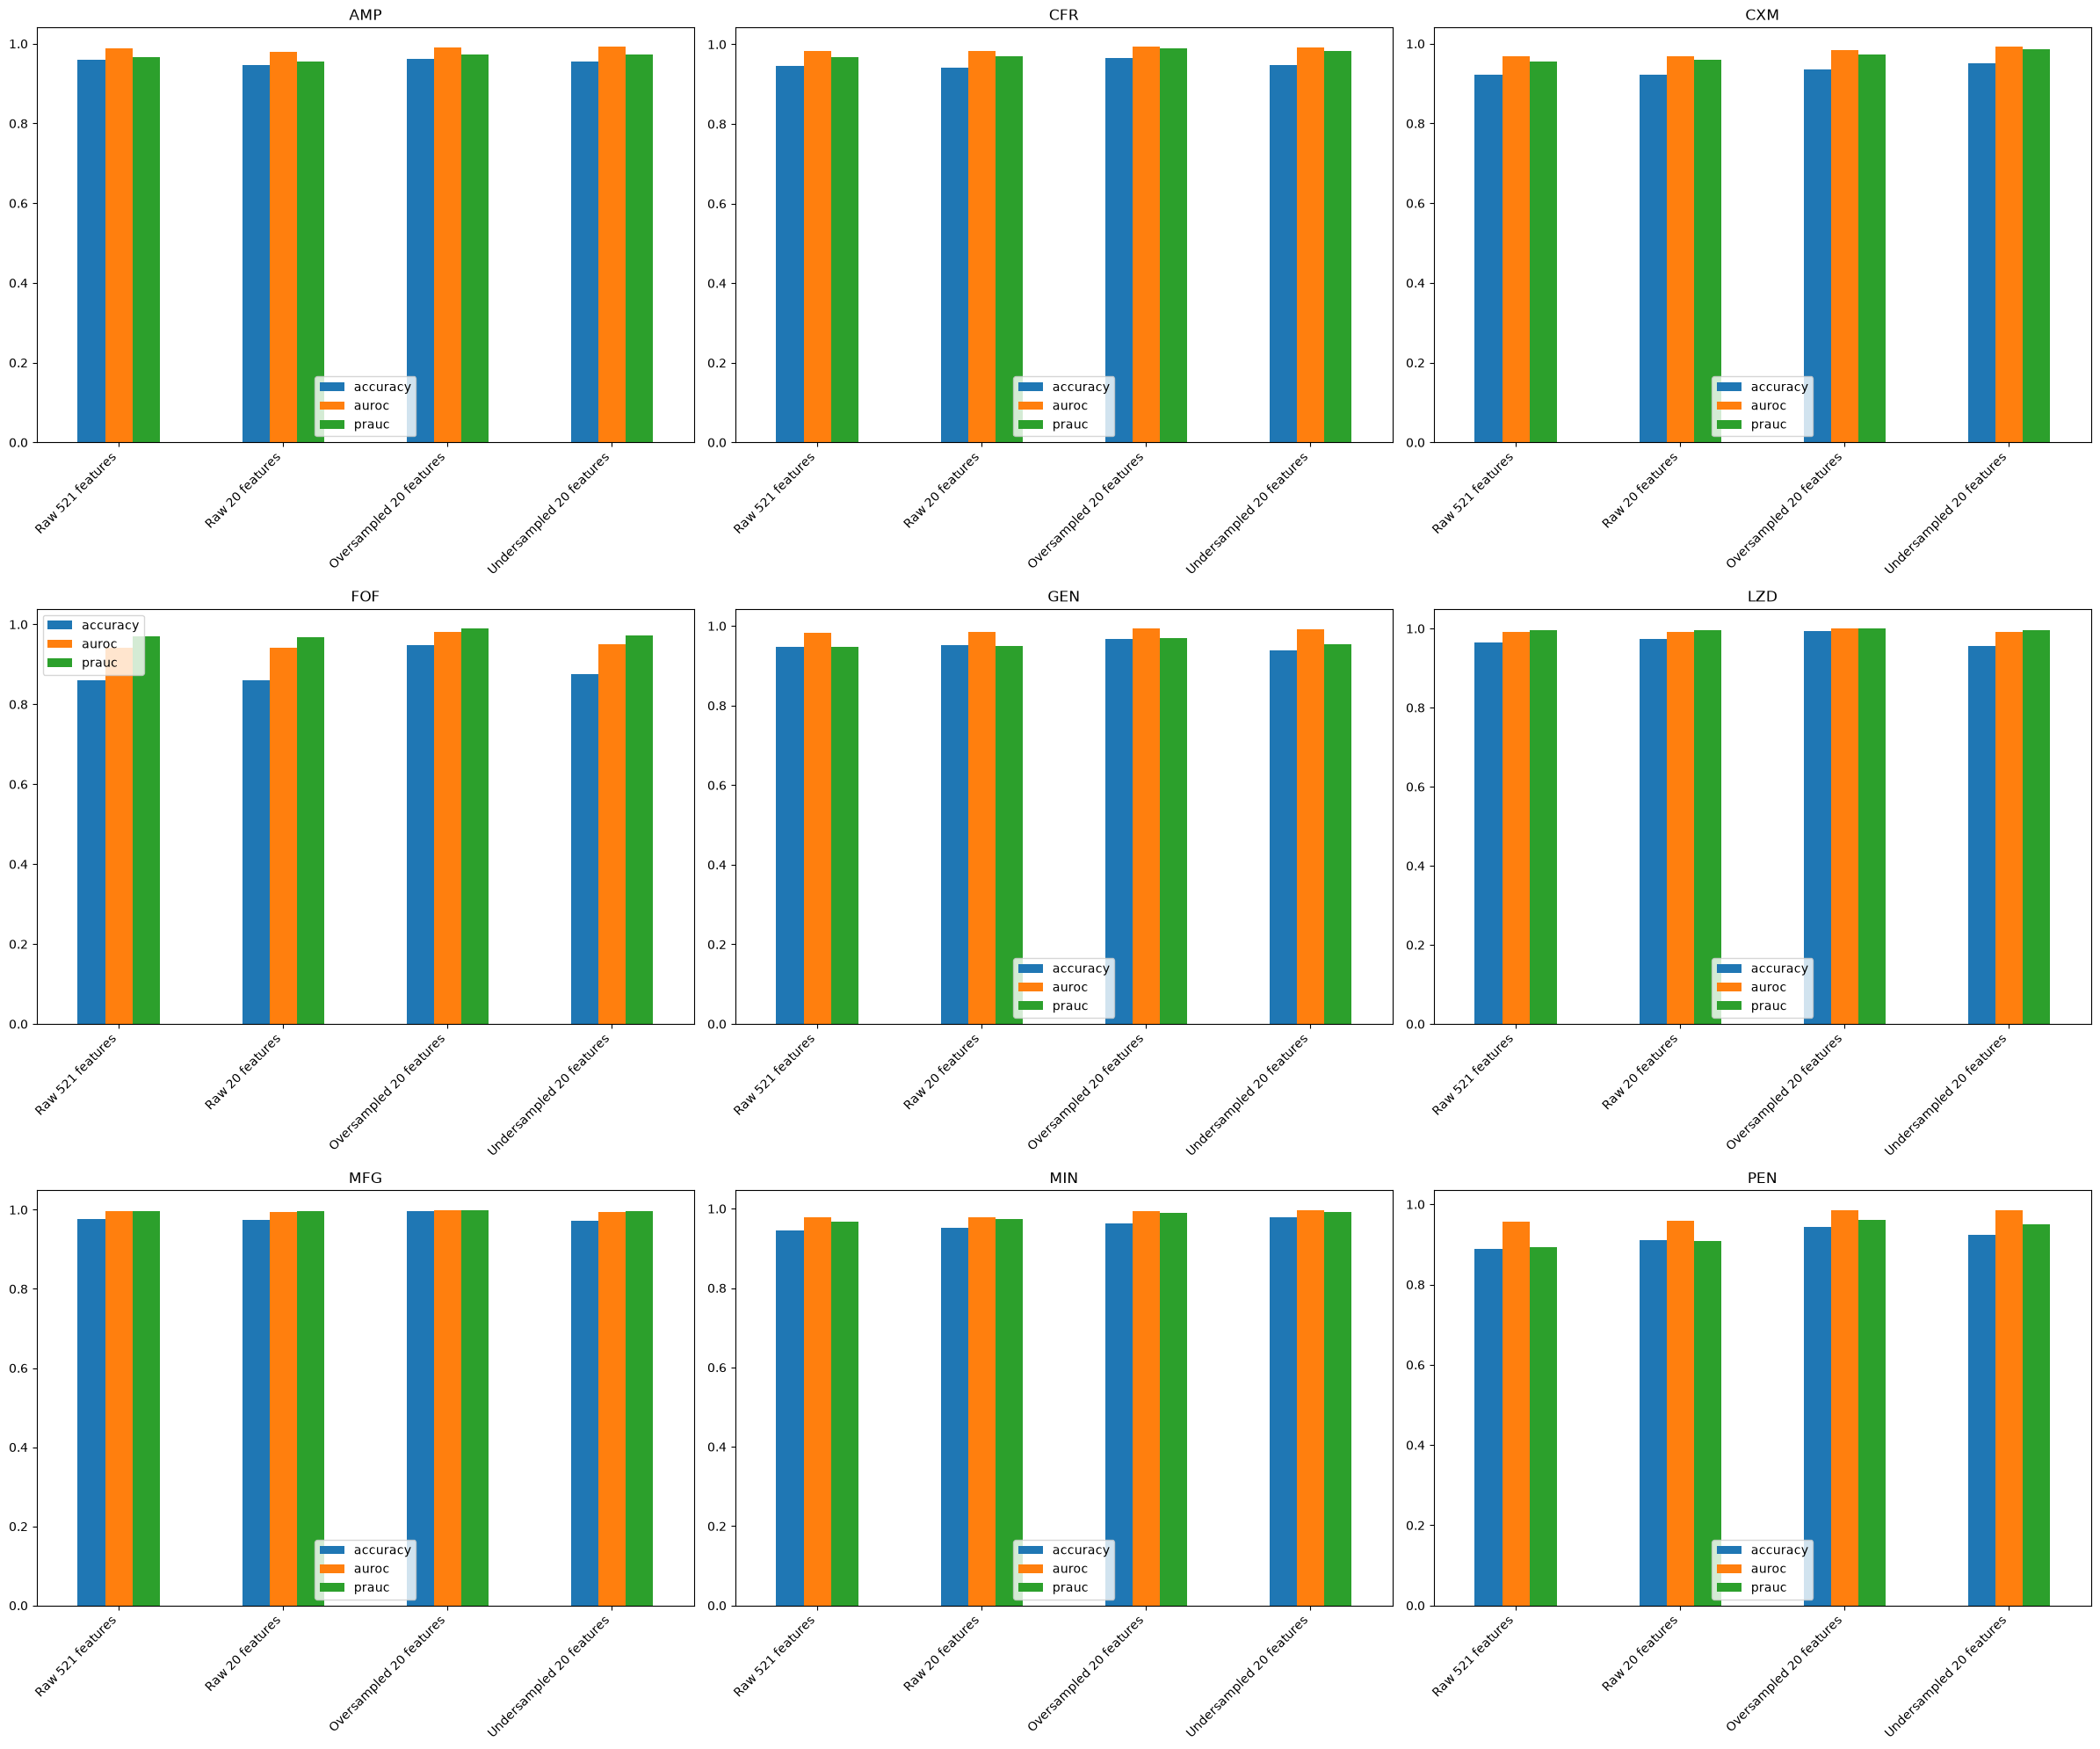

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
drugs_list = ['AMP', 'CFR', 'CXM', 'FOF', 'GEN', 'LZD', 'MFG', 'MIN', 'PEN']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24, 20))
axes_flat = axes.flatten()

for i in range(len(drugs_list)):
    DRUG = drugs_list[i]
    with open(f"CML Results/from-hpc/{DRUG}.txt", "r") as file:
        data = "".join(file.readlines()).split(DRUG)
        df = parsedata(data, False)
        conditions = [
            df["oversampled"],
            df["undersampled"]
        ]
        choices = [
            "Oversampled " + df["features"].astype(str) + " features",
            "Undersampled " + df["features"].astype(str) + " features"
        ]
        df["Labels"] = np.select(conditions, choices, default="Raw " + df["features"].astype(str) + " features")
        df.plot(kind="bar",y=["accuracy","auroc","prauc"], title=DRUG, x="Labels", ax=axes_flat[i])
        axes_flat[i].set_xticklabels(axes_flat[i].get_xticklabels(), rotation=45, ha='right')
        axes_flat[i].set_xlabel('')
plt.tight_layout()
plt.show()


In [31]:
def parseconfidence(data):
    data = data[1:]
    BLOCK_LENGTH = 5
    df = pd.DataFrame()
    df["oversampled"] = []
    df["undersampled"] = []
    df["features"] = []
    df["accuracy"] = []
    df["accuracy_l"] = []
    df["accuracy_u"] = []
    df["f1"] = []
    df["f1_l"] = []
    df["f1_u"] = []
    df["auroc"] = []
    df["auroc_l"] = []
    df["auroc_u"] = []
    df["prauc"] = []
    df["prauc_l"] = []
    df["prauc_u"] = []
    for i in range(len(data)//BLOCK_LENGTH):
        block = data[i*BLOCK_LENGTH:i*BLOCK_LENGTH+BLOCK_LENGTH]
        oversampled = "Over" in block[0]
        undersampled = "Under" in block[0]
        features = 20
        accuracy = float(block[1].split(";")[0])
        accuracy_l = float(block[1].split(";")[1].split(",")[0])
        accuracy_u = float(block[1].split(";")[1].split(",")[1])
        auroc = float(block[2].split(";")[0])
        auroc_l = float(block[2].split(";")[1].split(",")[0])
        auroc_u = float(block[2].split(";")[1].split(",")[1])
        prauc = float(block[3].split(";")[0])
        prauc_l = float(block[3].split(";")[1].split(",")[0])
        prauc_u = float(block[3].split(";")[1].split(",")[1])
        f1 = float(block[4].split(";")[0])
        f1_l = float(block[4].split(";")[1].split(",")[0])
        f1_u = float(block[4].split(";")[1].split(",")[1])
        df.loc[len(df)] = [oversampled, undersampled, features, accuracy, accuracy_l, accuracy_u, f1, f1_l, f1_u, auroc, auroc_l, auroc_u, prauc, prauc_l, prauc_u]
    return df
    

        

C:\Users\nihal\AppData\Local\Temp\ipykernel_26792\3204760292.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


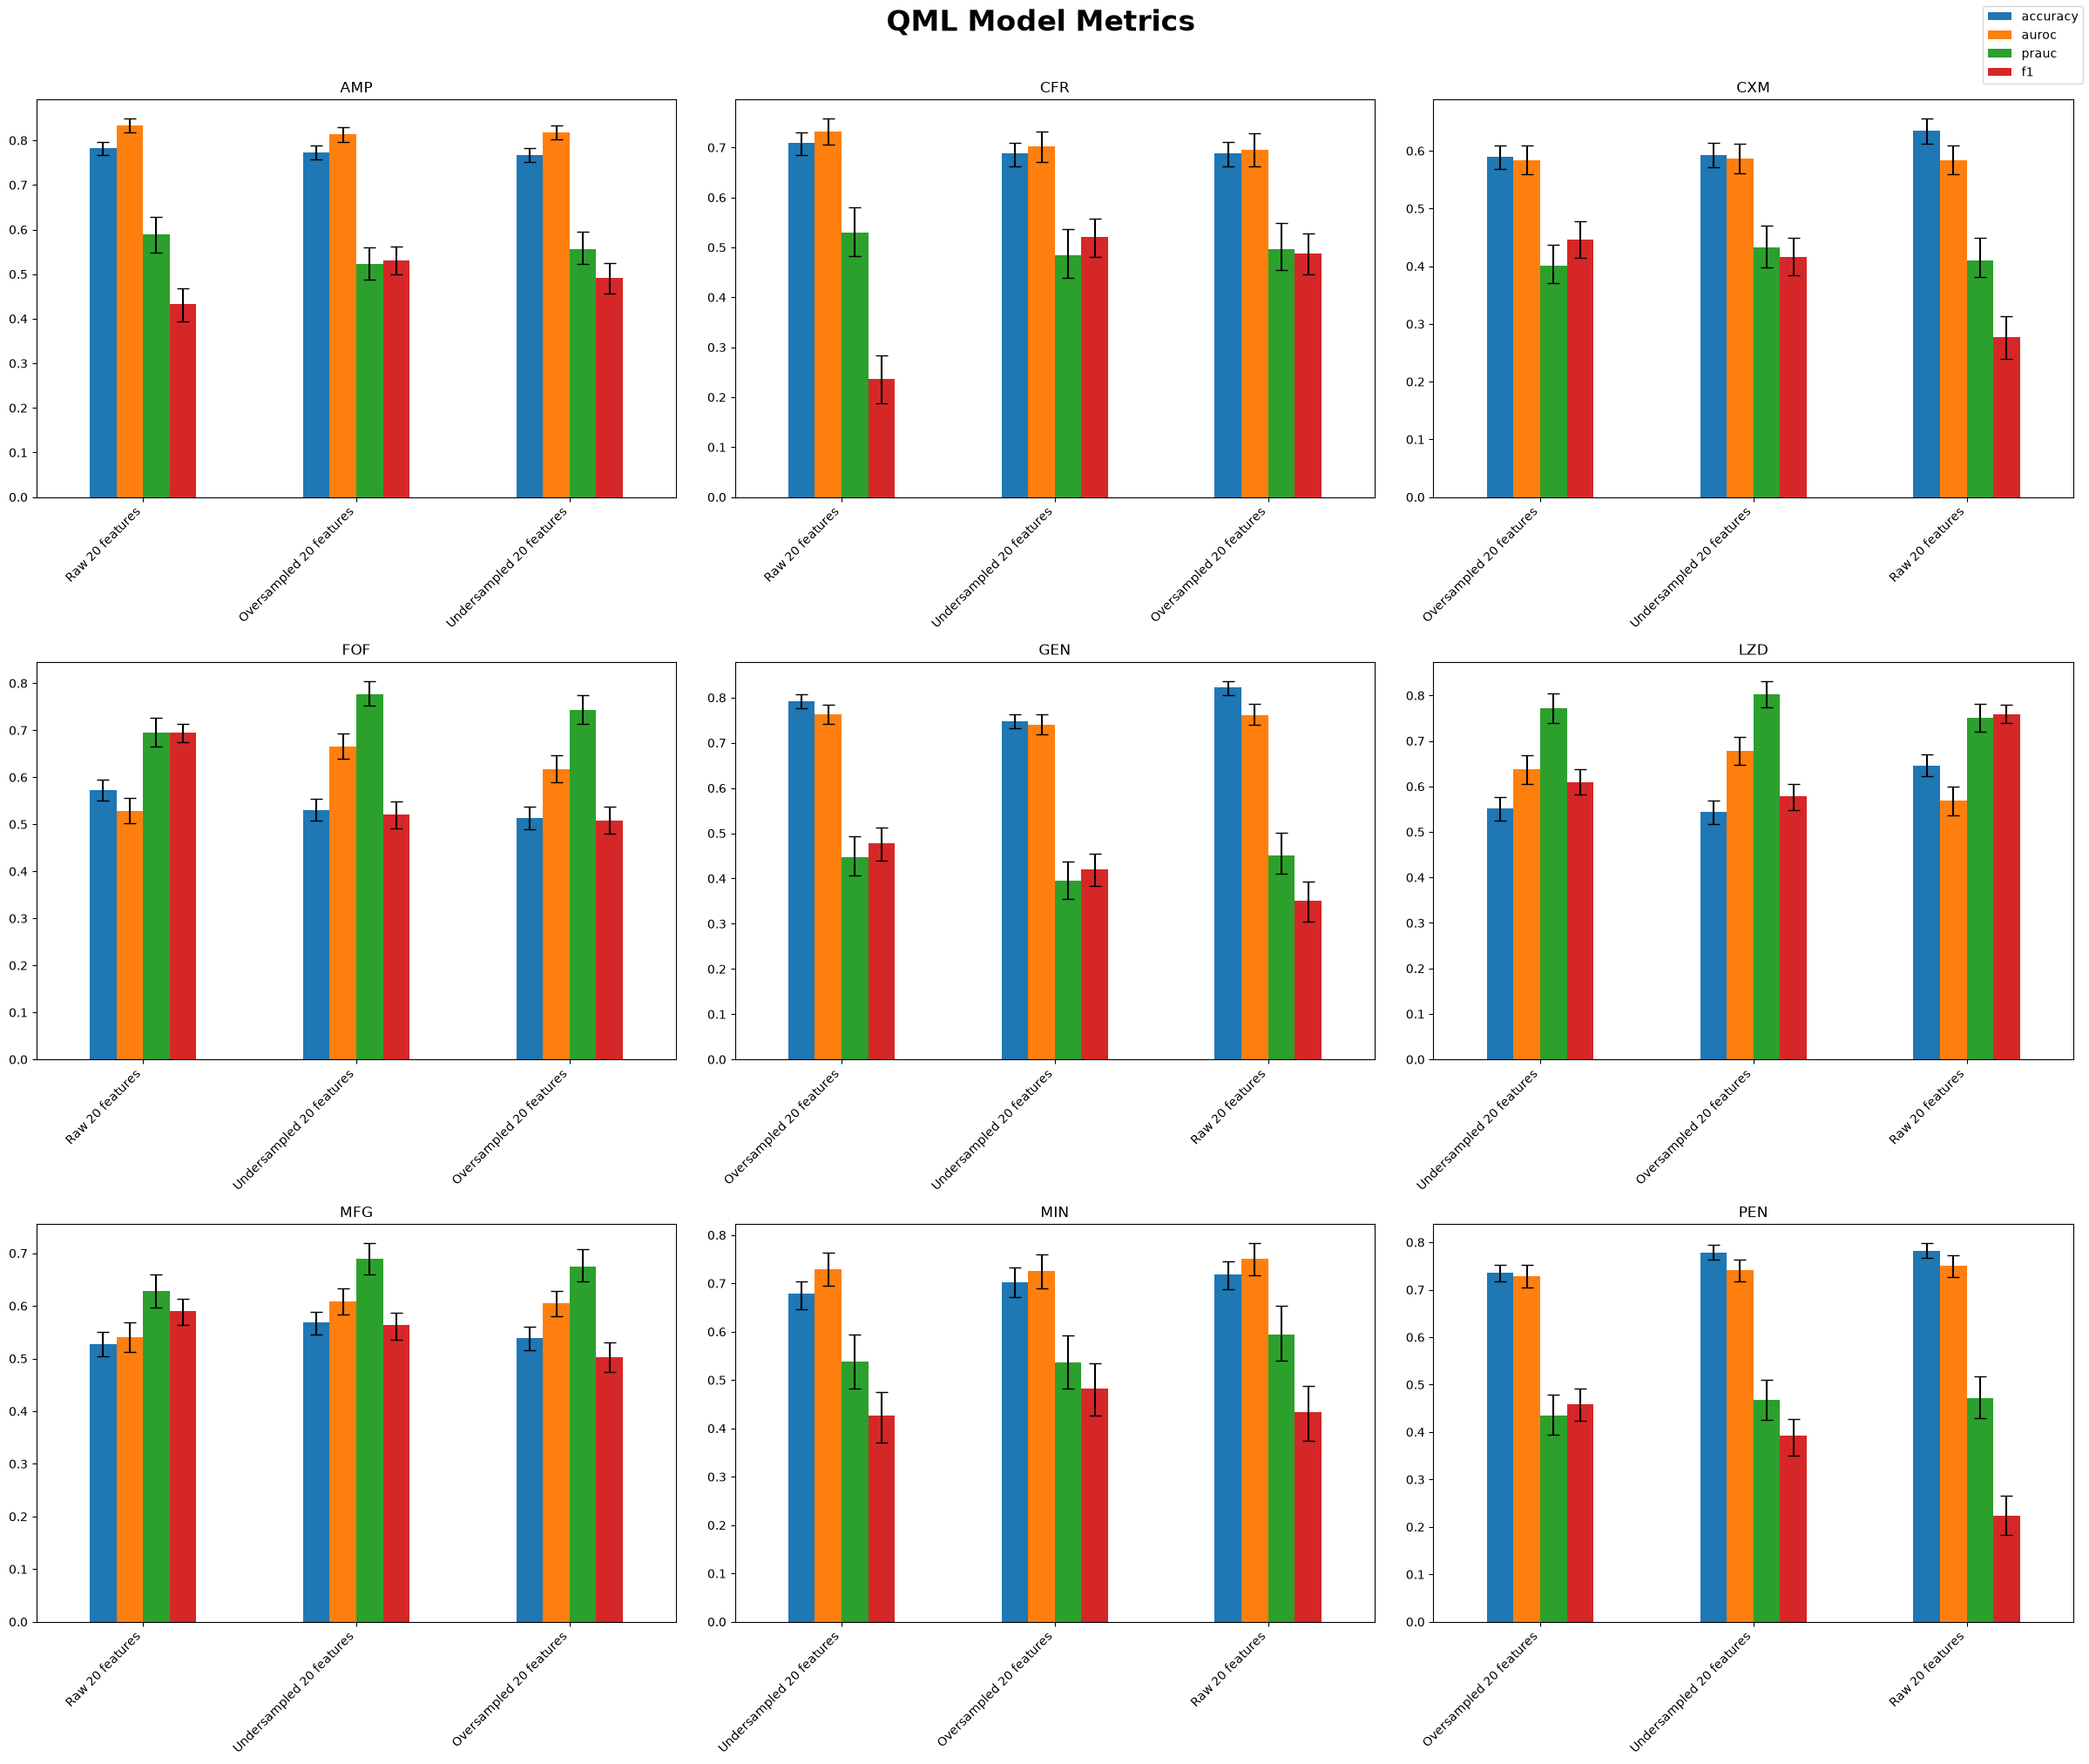

In [32]:
import matplotlib.pyplot as plt
import numpy as np
drugs_list = ['AMP', 'CFR', 'CXM', 'FOF', 'GEN', 'LZD', 'MFG', 'MIN', 'PEN']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24, 20), constrained_layout=True)
axes_flat = axes.flatten()
fig.suptitle("QML Model Metrics", fontsize=24, fontweight="bold", y=1.01)
for i in range(len(drugs_list)):
    DRUG = drugs_list[i]
    with open(f"QML Results/confidence/{DRUG}.txt", "r") as file:
        data = file.readlines()
        df = parseconfidence(data)
        conditions = [
            df["oversampled"],
            df["undersampled"]
        ]
        choices = [
            "Oversampled " + df["features"].astype(str) + " features",
            "Undersampled " + df["features"].astype(str) + " features"
        ]
        df["Labels"] = np.select(conditions, choices, default="Raw " + df["features"].astype(str) + " features")
        err_lower = df[["accuracy", "auroc", "prauc", "f1"]].values - df[["accuracy_l", "auroc_l", "prauc_l", "f1_l"]].values
        err_upper = df[["accuracy_u", "auroc_u", "prauc_u", "f1_u"]].values - df[["accuracy", "auroc", "prauc", "f1"]].values
        y_errors = np.stack([err_lower.T, err_upper.T], axis=1)
        df.plot(kind="bar",y=["accuracy","auroc","prauc","f1"], title=DRUG, x="Labels", ax=axes_flat[i], yerr=y_errors, capsize=5)
        axes_flat[i].set_xticklabels(axes_flat[i].get_xticklabels(), rotation=45, ha='right')
        axes_flat[i].set_xlabel('')
        axes_flat[i].get_legend().remove()
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles,labels,loc="upper right")

plt.tight_layout()
plt.show()